In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("archive")
TRAIN_PATH = DATA_DIR / "otto-recsys-train.jsonl"
TEST_PATH = DATA_DIR / "otto-recsys-test.jsonl"

In [16]:
### USING PANDAS TO EXPLORE JSON FILE ###

raw_df = pd.read_json(TRAIN_PATH, lines=True, nrows=50_000)
raw_df.head()

,session,events
0,0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':..."
1,1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ..."
2,2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ..."
3,3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':..."
4,4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ..."


In [17]:
exploded = raw_df.explode("events")                 # one row per event, but "events" is still a dict per cell
events_df = pd.json_normalize(exploded["events"])    # expands each dict into its own columns (aid, ts, type)
events_df["session"] = exploded["session"].values    # reattach the session id
events_df.head()

### END OF USING PANDAS TO EXPLORE JSON FILE ###

,aid,ts,type,session
0,1517085,1659304800025,clicks,0
1,1563459,1659304904511,clicks,0
2,1309446,1659367439426,clicks,0
3,16246,1659367719997,clicks,0
4,1781822,1659367871344,clicks,0


In [3]:
### USING LOOP TO EXPLORE JSON FILE AND SET AS DATAFRAME ###

with open(TRAIN_PATH) as f:
    for i, line in enumerate(f):
        if i >=3:
            break
        print(json.loads(line))

{'session': 0, 'events': [{'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'}, {'aid': 1563459, 'ts': 1659304904511, 'type': 'clicks'}, {'aid': 1309446, 'ts': 1659367439426, 'type': 'clicks'}, {'aid': 16246, 'ts': 1659367719997, 'type': 'clicks'}, {'aid': 1781822, 'ts': 1659367871344, 'type': 'clicks'}, {'aid': 1152674, 'ts': 1659367885796, 'type': 'clicks'}, {'aid': 1649869, 'ts': 1659369893840, 'type': 'carts'}, {'aid': 461689, 'ts': 1659369898050, 'type': 'carts'}, {'aid': 305831, 'ts': 1659370027105, 'type': 'orders'}, {'aid': 461689, 'ts': 1659370027105, 'type': 'orders'}, {'aid': 362233, 'ts': 1659370064916, 'type': 'clicks'}, {'aid': 1649869, 'ts': 1659370067686, 'type': 'clicks'}, {'aid': 1649869, 'ts': 1659371003682, 'type': 'clicks'}, {'aid': 984597, 'ts': 1659371033243, 'type': 'clicks'}, {'aid': 1649869, 'ts': 1659371042297, 'type': 'clicks'}, {'aid': 803544, 'ts': 1659371044075, 'type': 'clicks'}, {'aid': 1110941, 'ts': 1659371104329, 'type': 'clicks'}, {'aid': 1190046

In [6]:
SAMPLE_SIZE = 50_000

sessions = []
with open(TRAIN_PATH) as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
        sessions.append(json.loads(line))

print(f"Loaded {len(sessions)} sessions")

Loaded 50000 sessions


In [7]:
## flatten the records into a dataframe ##

rows = []
for s in sessions:
    for e in s["events"]:
        rows.append({"session": s["session"], "aid": e["aid"], "ts": e["ts"], "type": e["type"]})

events_df = pd.DataFrame(rows)
events_df["ts"] = pd.to_datetime(events_df["ts"], unit="ms")
events_df.head()

### END OF USING LOOP TO EXPLORE JSON FILE AND SET AS DATAFRAME ###

,session,aid,ts,type
0,0,1517085,2022-07-31 22:00:00.025,clicks
1,0,1563459,2022-07-31 22:01:44.511,clicks
2,0,1309446,2022-08-01 15:23:59.426,clicks
3,0,16246,2022-08-01 15:28:39.997,clicks
4,0,1781822,2022-08-01 15:31:11.344,clicks


In [9]:
events_df["type"].value_counts()

type
clicks    2395745
carts      180595
orders      44770
Name: count, dtype: int64

In [10]:
events_df["type"].value_counts(normalize=True)

type
clicks    0.914019
carts     0.068900
orders    0.017081
Name: proportion, dtype: float64

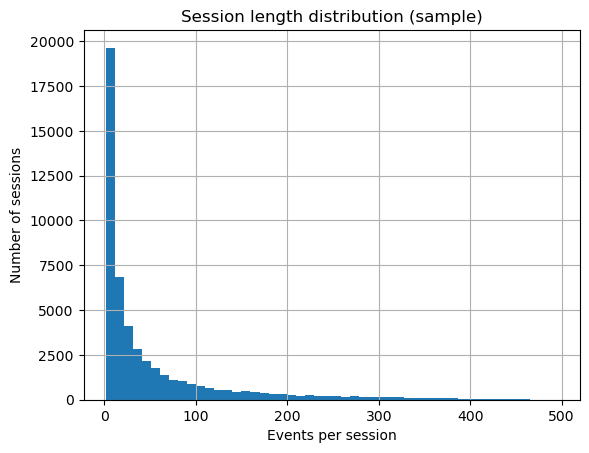

In [11]:
session_lengths = events_df.groupby("session").size()
session_lengths.describe()

session_lengths.hist(bins=50)
plt.xlabel("Events per session")
plt.ylabel("Number of sessions")
plt.title("Session length distribution (sample)")
plt.show()

In [12]:
total = events_df["session"].nunique()
has_cart = events_df[events_df["type"] == "carts"]["session"].nunique()
has_order = events_df[events_df["type"] == "orders"]["session"].nunique()

print(f"Sessions: {total}")
print(f"With >=1 cart:  {has_cart} ({has_cart/total:.1%})")
print(f"With >=1 order: {has_order} ({has_order/total:.1%})")

Sessions: 50000
With >=1 cart:  23024 (46.0%)
With >=1 order: 11481 (23.0%)


In [13]:
print(events_df["ts"].min(), "to", events_df["ts"].max())

2022-07-31 22:00:00.025000 to 2022-08-28 21:59:59.941000


In [19]:
len(events_df)

2621110

In [18]:
events_df["aid"].nunique()

450103

In [20]:
### USING PANDAS TO EXPLORE AND CHUNK THE HUGE FILE ###

chunks = pd.read_json(TRAIN_PATH, lines=True, chunksize=100_000)

total_events = 0
unique_aids = set()

for chunk in chunks:
    events_chunk = pd.json_normalize(chunk.explode("events")["events"])
    total_events += len(events_chunk)
    unique_aids.update(events_chunk["aid"])

print(f"Total events: {total_events:,}")
print(f"Unique aid:   {len(unique_aids):,}")

Total events: 216,716,096
Unique aid:   1,855,603


AttributeError: 'JsonReader' object has no attribute 'shape'